# Effect of Processing Time Variation

This experiment compares three service-duration distributions with the same expected duration of four time steps:

| Scenario | Variation parameter | Service duration | Expected duration |
| --- | ---: | --- | ---: |
| Fixed | 0 | Always 4 | 4 |
| Low variation | 1 | Discrete uniform from 3 to 5 | 4 |
| High variation | 3 | Discrete uniform from 1 to 7 | 4 |

Arrival probability, queue capacity, and the number of checkpoints are held constant. Each scenario is repeated with 30 random seeds. Each simulation starts empty and runs for 5,000 time steps.

**Research question:** How does service-duration variability affect waiting time and congestion when expected service duration is held constant?

## Setup

Install the project dependencies using `python -m pip install -r requirements.txt`. Select that Python environment as the notebook kernel. Run this notebook from the project root or its `notebooks` directory.

The model is imported from `src`; its implementation is not duplicated here. Restart the kernel and run all cells after changing a model file.


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

project_root = next(
    (
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "src" / "model.py").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Start the notebook from the project root or the notebooks directory."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.model import AirportSecurityModel

## Experimental Design

- Arrival probability: 0.4 per time step; at most one passenger arrives per step.
- Queue capacity: 10 waiting passengers per checkpoint, excluding passengers in service.
- Checkpoints: 2.
- Expected service duration: 4 time steps.
- Simulation length: 5,000 time steps, with no warm-up period removed.
- Seeds: 0 through 29 for each scenario.

The same seed list makes the experiment reproducible. It does **not** guarantee identical arrival sequences across scenarios: the current model shares one random number generator between arrival and service-duration sampling.

Mean waiting time is calculated only for passengers who finish screening within the observation period, and includes both external and internal waiting. Unfinished passengers are recorded separately. Queue lengths are sampled at the end of each model step. Throughput is completed passengers divided by the number of simulation steps.

In [2]:
scenarios = {
    "Fixed": 0,
    "Low variation": 1,
    "High variation": 3,
}

simulation_steps = 5000
seeds = range(30)
base_parameters = {
    "arrival_rate": 0.4,
    "queue_capacity": 10,
    "num_checkpoints": 2,
    "processing_time": 4,
    "simulation_steps": simulation_steps,
}
experiment_results = []

for scenario, variation in scenarios.items():
    for seed in seeds:
        model = AirportSecurityModel(
            **base_parameters,
            processing_time_variation=variation,
            seed=seed,
        )
        model.run()

        completed_waits = [
            passenger.waiting_time
            for passenger in model.completed_passengers
        ]
        completed_count = len(model.completed_passengers)
        unfinished_count = len(model.all_passengers) - completed_count

        experiment_results.append({
            **base_parameters,
            "scenario": scenario,
            "variation": variation,
            "seed": seed,
            "mean_completed_wait": (
                float(np.mean(completed_waits))
                if completed_waits else np.nan
            ),
            "mean_internal_queue": float(
                np.mean(model.queue_length_history)
            ),
            "mean_external_queue": float(
                np.mean(model.external_waiting_history)
            ),
            "throughput_rate": completed_count / simulation_steps,
            "arrived_passengers": len(model.all_passengers),
            "completed_passengers": completed_count,
            "unfinished_passengers": unfinished_count,
        })

print(f"Completed {len(experiment_results)} simulation runs.")

Completed 90 simulation runs.


## Summary Across Repeated Runs

Each run receives equal weight. The standard deviation below describes variation **between run mean waiting times**, not variation between individual passengers and not a confidence interval. Runs without any completed passengers have undefined mean waiting time and are counted explicitly.

In [3]:
summary_results = []

for scenario in scenarios:
    runs = [
        result for result in experiment_results
        if result["scenario"] == scenario
    ]
    waits = np.array([run["mean_completed_wait"] for run in runs])
    valid_waits = waits[np.isfinite(waits)]

    summary_results.append({
        "scenario": scenario,
        "runs": len(runs),
        "valid_wait_runs": len(valid_waits),
        "mean_wait": (
            float(np.mean(valid_waits)) if len(valid_waits) else np.nan
        ),
        "sd_wait": (
            float(np.std(valid_waits, ddof=1))
            if len(valid_waits) > 1 else np.nan
        ),
        "mean_internal_queue": float(np.mean([
            run["mean_internal_queue"] for run in runs
        ])),
        "mean_external_queue": float(np.mean([
            run["mean_external_queue"] for run in runs
        ])),
        "mean_throughput_rate": float(np.mean([
            run["throughput_rate"] for run in runs
        ])),
        "mean_unfinished_passengers": float(np.mean([
            run["unfinished_passengers"] for run in runs
        ])),
    })

for result in summary_results:
    print(result["scenario"])
    print(f"  Runs: {result['runs']}")
    print(f"  Runs with completed passengers: {result['valid_wait_runs']}")
    print(
        f"  Completed-passenger mean wait: "
        f"{result['mean_wait']:.2f} time steps"
    )
    print(f"  SD of run mean waits: {result['sd_wait']:.2f} time steps")
    print(
        f"  Mean internal queue: "
        f"{result['mean_internal_queue']:.2f} passengers"
    )
    print(
        f"  Mean external queue: "
        f"{result['mean_external_queue']:.2f} passengers"
    )
    print(
        f"  Mean throughput: "
        f"{result['mean_throughput_rate']:.3f} passengers per time step"
    )
    print(
        f"  Mean unfinished passengers at end: "
        f"{result['mean_unfinished_passengers']:.2f}"
    )
    print()

Fixed
  Runs: 30
  Runs with completed passengers: 30
  Completed-passenger mean wait: 1.96 time steps
  SD of run mean waits: 0.25 time steps
  Mean internal queue: 0.78 passengers
  Mean external queue: 0.00 passengers
  Mean throughput: 0.399 passengers per time step
  Mean unfinished passengers at end: 2.37

Low variation
  Runs: 30
  Runs with completed passengers: 30
  Completed-passenger mean wait: 2.12 time steps
  SD of run mean waits: 0.31 time steps
  Mean internal queue: 0.85 passengers
  Mean external queue: 0.00 passengers
  Mean throughput: 0.399 passengers per time step
  Mean unfinished passengers at end: 1.87

High variation
  Runs: 30
  Runs with completed passengers: 30
  Completed-passenger mean wait: 2.90 time steps
  SD of run mean waits: 0.51 time steps
  Mean internal queue: 1.16 passengers
  Mean external queue: 0.00 passengers
  Mean throughput: 0.399 passengers per time step
  Mean unfinished passengers at end: 2.43



## Scenario Comparison

Bars show means across 30 independent runs per scenario. The waiting-time error bars show **one standard deviation of run means**, not confidence intervals or variation between individual passengers. Queue, throughput, and unfinished-passenger panels show means only. All axes start at zero.

Internal and external queues are shown separately. Exact zeros are labelled explicitly. Waiting times include only completed passengers; the final panel reports those still unfinished.

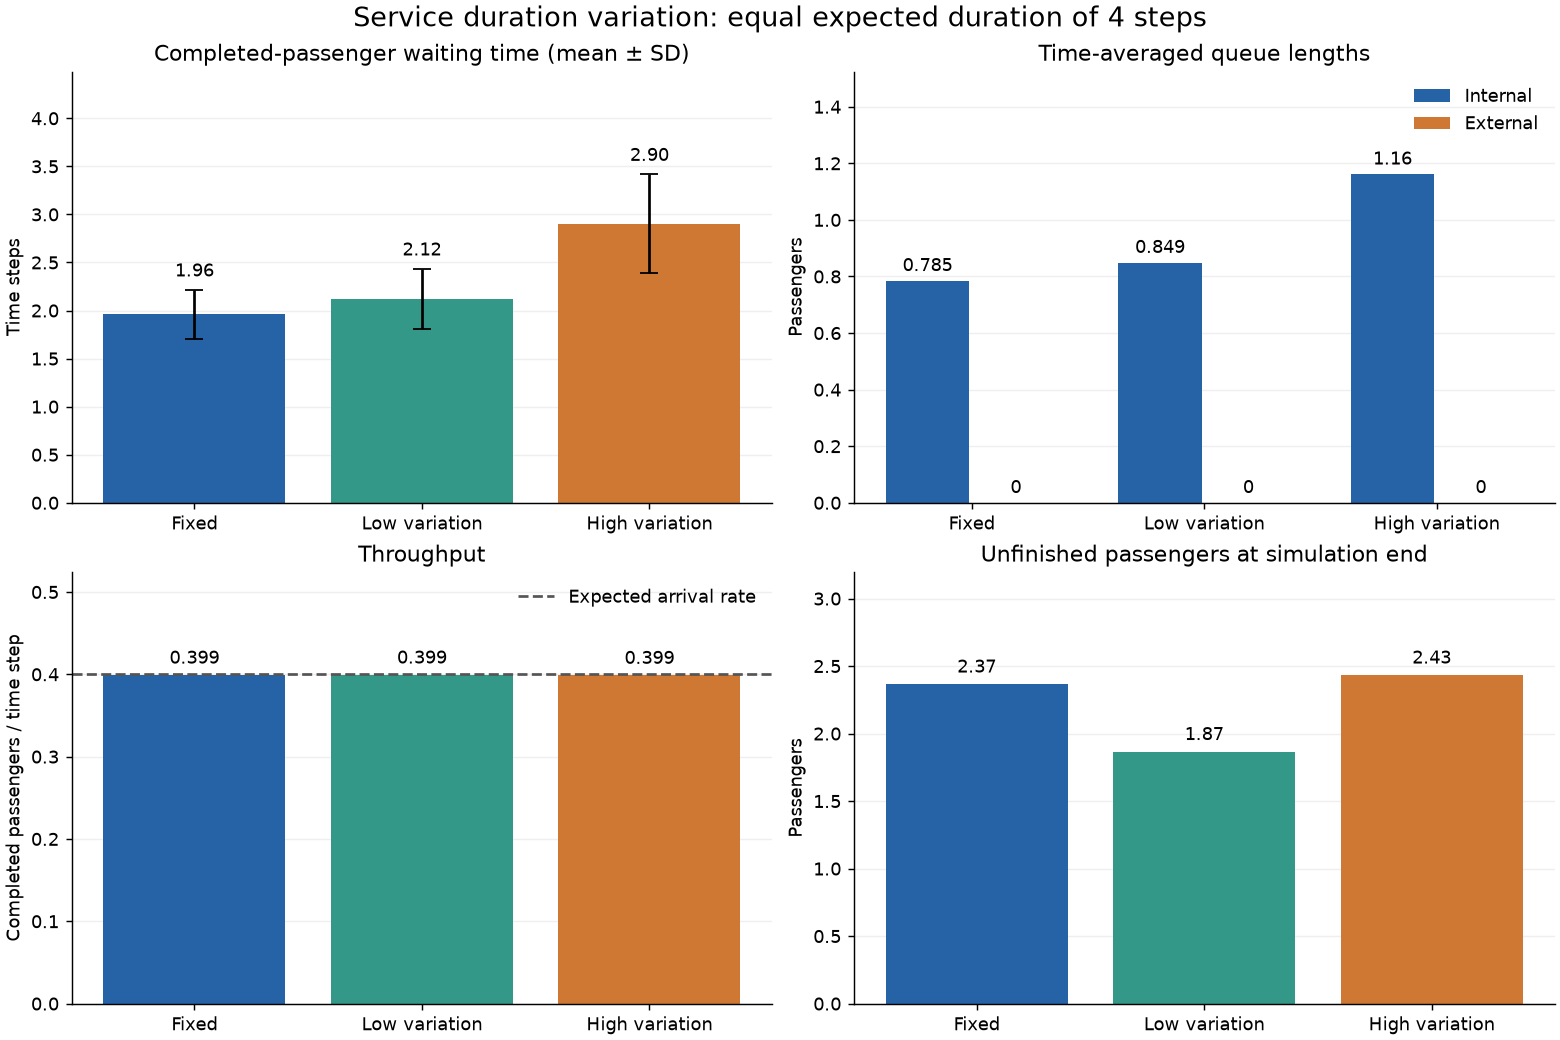

In [4]:
labels = [result["scenario"] for result in summary_results]
x = np.arange(len(labels))
colors = ["#2563A6", "#349889", "#CE7833"]

with plt.rc_context({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False}):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
    fig.suptitle("Service duration variation: equal expected duration of 4 steps", fontsize=15)

    waits = [result["mean_wait"] for result in summary_results]
    errors = [result["sd_wait"] for result in summary_results]
    bars = axes[0, 0].bar(x, waits, yerr=errors, capsize=5, color=colors)
    axes[0, 0].bar_label(bars, fmt="%.2f", padding=5)
    axes[0, 0].set(title="Completed-passenger waiting time (mean ± SD)", ylabel="Time steps")

    for offset, key, label, color in [
        (-0.19, "mean_internal_queue", "Internal", "#2563A6"),
        (0.19, "mean_external_queue", "External", "#CE7833"),
    ]:
        values = [result[key] for result in summary_results]
        bars = axes[0, 1].bar(x + offset, values, width=0.36, label=label, color=color)
        axes[0, 1].bar_label(bars, labels=[f"{v:.3g}" for v in values], padding=3)
    axes[0, 1].set(title="Time-averaged queue lengths", ylabel="Passengers")
    axes[0, 1].legend(frameon=False)

    rates = [result["mean_throughput_rate"] for result in summary_results]
    bars = axes[1, 0].bar(x, rates, color=colors)
    axes[1, 0].bar_label(bars, fmt="%.3f", padding=4)
    axes[1, 0].axhline(base_parameters["arrival_rate"], color="#555555", linestyle="--",
                       label="Expected arrival rate")
    axes[1, 0].set(title="Throughput", ylabel="Completed passengers / time step")
    axes[1, 0].legend(frameon=False)

    unfinished = [result["mean_unfinished_passengers"] for result in summary_results]
    bars = axes[1, 1].bar(x, unfinished, color=colors)
    axes[1, 1].bar_label(bars, fmt="%.2f", padding=4)
    axes[1, 1].set(title="Unfinished passengers at simulation end", ylabel="Passengers")

    for ax in axes.flat:
        ax.set_xticks(x, labels)
        ax.set_ylim(0, max(ax.get_ylim()[1] * 1.25, 0.1))
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)
    plt.show()

### Reading the Comparison

Under the default settings, mean completed-passenger waiting time rises from about 1.96 steps (fixed) to 2.12 (low variation) and 2.90 (high variation), while throughput remains close to 0.399 passengers per step. Similar throughput can coexist with greater congestion and longer waits.

These values describe the saved default experiment. Rerun the notebook and update this interpretation if parameters change; the error bars alone do not establish statistical significance.

## Interpretation and Limitations

Compare waiting times and internal and external queue lengths together. The internal queues have limited capacity; additional congestion can accumulate in the external waiting area. Similar throughput does not imply similar waiting times.

These are finite-horizon results from an initially empty system, not a demonstrated steady-state analysis. Waiting-time estimates exclude passengers who have not completed screening when the simulation ends, which can understate waiting under congestion. Inspect unfinished-passenger counts when interpreting scenario differences.

The three service distributions have the same theoretical mean. Their finite-sample means need not be exactly equal. Differences between scenario means are descriptive; the reported standard deviations alone do not establish statistical significance.